In [10]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap streamlit imbalanced-learn

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 616.7 kB/s eta 0:02:45
   ---------------------------------------- 0.5/101.7 MB 616.7 kB/s eta 0:02:45
   ---------------------------------------- 0.8/101.7 MB 529.8 kB/s eta 0:03:11
   ---------------------------------------- 0.8/101.7 MB 529

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
import os

In [7]:
import warnings

In [8]:
warnings.filterwarnings("ignore")

In [9]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [13]:
hypertension_df = pd.read_csv("C:/Users/Esther Momeke/Downloads/hypertension_data.csv")
diabetes_df     = pd.read_csv("C:/Users/Esther Momeke/Downloads/diabetes_data.csv")
stroke_df       = pd.read_csv("C:/Users/Esther Momeke/Downloads/stroke_data.csv")

In [16]:
# .shape tells us how many rows and columns each dataset has
print("Dataset sizes:")
print(f"  Hypertension dataset : {hypertension_df.shape[0]:,} rows, {hypertension_df.shape[1]} columns")
print(f"  Diabetes dataset     : {diabetes_df.shape[0]:,} rows, {diabetes_df.shape[1]} columns")
print(f"  Stroke dataset       : {stroke_df.shape[0]:,} rows, {stroke_df.shape[1]} columns")

Dataset sizes:
  Hypertension dataset : 26,083 rows, 14 columns
  Diabetes dataset     : 70,692 rows, 18 columns
  Stroke dataset       : 40,910 rows, 11 columns


In [17]:
print("=== HYPERTENSION DATASET — Column types ===")
print(hypertension_df.dtypes)

print("\n=== DIABETES DATASET — Column types ===")
print(diabetes_df.dtypes)

print("\n=== STROKE DATASET — Column types ===")
print(stroke_df.dtypes)

=== HYPERTENSION DATASET — Column types ===
age         float64
sex         float64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

=== DIABETES DATASET — Column types ===
Age                     float64
Sex                     float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Stroke                  float64
HighBP                  float64
Diabetes                float64
dtype: object

=== STROKE DATASET — Column ty

In [18]:
print("=== MISSING VALUES — HYPERTENSION DATASET ===")
missing_hyp = hypertension_df.isnull().sum()
print(missing_hyp[missing_hyp > 0] if missing_hyp.sum() > 0 else "✓ No missing values")

print("\n=== MISSING VALUES — DIABETES DATASET ===")
missing_dia = diabetes_df.isnull().sum()
print(missing_dia[missing_dia > 0] if missing_dia.sum() > 0 else "✓ No missing values")

print("\n=== MISSING VALUES — STROKE DATASET ===")
missing_str = stroke_df.isnull().sum()
print(missing_str[missing_str > 0] if missing_str.sum() > 0 else "✓ No missing values")

=== MISSING VALUES — HYPERTENSION DATASET ===
sex    25
dtype: int64

=== MISSING VALUES — DIABETES DATASET ===
✓ No missing values

=== MISSING VALUES — STROKE DATASET ===
sex    3
dtype: int64


In [19]:
# This is a plain Python dictionary — think of it as a lookup table
# where the key is the column name and the value is the explanation

print("=" * 60)
print("HYPERTENSION DATASET — What each column means")
print("=" * 60)

hypertension_dict = {
    "age"      : "Patient age in years",
    "sex"      : "1 = male, 0 = female",
    "cp"       : "Chest pain type: 0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic",
    "trestbps" : "Resting blood pressure in mmHg (normal is around 120)",
    "chol"     : "Serum cholesterol in mg/dl (normal is below 200)",
    "fbs"      : "Fasting blood sugar > 120mg/dl — 1=yes (diabetic risk), 0=no",
    "restecg"  : "Resting ECG result: 0=normal, 1=ST-T wave abnormality, 2=left ventricular hypertrophy",
    "thalach"  : "Maximum heart rate achieved during exercise",
    "exang"    : "Did exercise cause chest pain (angina)? 1=yes, 0=no",
    "oldpeak"  : "ST depression on ECG during exercise compared to rest (higher = worse)",
    "slope"    : "Slope of the peak exercise ST segment: 0=upsloping, 1=flat, 2=downsloping",
    "ca"       : "Number of major heart vessels blocked (0=none, 3=very severe)",
    "thal"     : "Thalassemia blood disorder: 1=normal, 2=fixed defect, 3=reversable defect",
    "target"   : ">>> IHD LABEL <<< 1 = heart disease present, 0 = no heart disease"
}

for column_name, explanation in hypertension_dict.items():
    print(f"  {column_name:<12} → {explanation}")

HYPERTENSION DATASET — What each column means
  age          → Patient age in years
  sex          → 1 = male, 0 = female
  cp           → Chest pain type: 0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic
  trestbps     → Resting blood pressure in mmHg (normal is around 120)
  chol         → Serum cholesterol in mg/dl (normal is below 200)
  fbs          → Fasting blood sugar > 120mg/dl — 1=yes (diabetic risk), 0=no
  restecg      → Resting ECG result: 0=normal, 1=ST-T wave abnormality, 2=left ventricular hypertrophy
  thalach      → Maximum heart rate achieved during exercise
  exang        → Did exercise cause chest pain (angina)? 1=yes, 0=no
  oldpeak      → ST depression on ECG during exercise compared to rest (higher = worse)
  slope        → Slope of the peak exercise ST segment: 0=upsloping, 1=flat, 2=downsloping
  ca           → Number of major heart vessels blocked (0=none, 3=very severe)
  thal         → Thalassemia blood disorder: 1=normal, 2=fixed defect, 3=rever

In [20]:
# value_counts() counts how many times each unique value appears in a column
# The target column: 1 = has IHD, 0 = does not have IHD

print("=== TARGET VARIABLE DISTRIBUTION ===")
print("\nHypertension dataset (IHD label = 'target' column):")

target_counts = hypertension_df["target"].value_counts().sort_index()
total = len(hypertension_df)

for label, count in target_counts.items():
    label_name = "IHD Present (1)" if label == 1 else "No IHD     (0)"
    bar = "█" * int(count / 100)   # visual bar
    print(f"  {label_name} : {count:,} patients ({count/total*100:.1f}%)  {bar}")

ratio = target_counts[1] / target_counts[0]
print(f"\n  Balance ratio: {ratio:.2f}  (1.0 = perfectly balanced)")
print("  → Ratio is close to 1 = good! No severe class imbalance problem.")

print("\nDiabetes dataset (IHD label = 'HeartDiseaseorAttack' column):")
hd_counts = diabetes_df["HeartDiseaseorAttack"].value_counts().sort_index()
for label, count in hd_counts.items():
    print(f"  {label} : {count:,} ({count/len(diabetes_df)*100:.1f}%)")

=== TARGET VARIABLE DISTRIBUTION ===

Hypertension dataset (IHD label = 'target' column):
  No IHD     (0) : 11,809 patients (45.3%)  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  IHD Present (1) : 14,274 patients (54.7%)  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

  Balance ratio: 1.21  (1.0 = perfectly balanced)
  → Ratio is close to 1 = good! No severe class imbalance problem.

Diabetes dataset (IHD label = 'HeartDiseaseorAttack' column):
  0.0 : 60,243 (85.2%)
  1.0 : 10,449 (14.8%)


In [21]:
# .describe() gives count, mean, std, min, 25%, 50%, 75%, max for every column
# .round(2) rounds to 2 decimal places to keep it readable
# .T transposes (flips) the table so features are on rows, stats on columns

print("=== HYPERTENSION DATASET — Basic Statistics ===")
print(hypertension_df.describe().round(2).T.to_string())

print("\n=== DIABETES DATASET — Basic Statistics ===")
print(diabetes_df.describe().round(2).T.to_string())

print("\n=== STROKE DATASET — Basic Statistics ===")
print(stroke_df.describe().round(2).T.to_string())

=== HYPERTENSION DATASET — Basic Statistics ===
            count    mean    std    min    25%    50%    75%    max
age       26083.0   55.66  15.19   11.0   44.0   56.0   67.0   98.0
sex       26058.0    0.50   0.50    0.0    0.0    0.5    1.0    1.0
cp        26083.0    0.96   1.02    0.0    0.0    1.0    2.0    3.0
trestbps  26083.0  131.59  17.59   94.0  120.0  130.0  140.0  200.0
chol      26083.0  246.25  51.64  126.0  211.0  240.0  275.0  564.0
fbs       26083.0    0.15   0.36    0.0    0.0    0.0    0.0    1.0
restecg   26083.0    0.53   0.53    0.0    0.0    1.0    1.0    2.0
thalach   26083.0  149.66  22.86   71.0  133.0  153.0  166.0  202.0
exang     26083.0    0.33   0.47    0.0    0.0    0.0    1.0    1.0
oldpeak   26083.0    1.04   1.17    0.0    0.0    0.8    1.6    6.2
slope     26083.0    1.40   0.62    0.0    1.0    1.0    2.0    2.0
ca        26083.0    0.72   1.01    0.0    0.0    0.0    1.0    4.0
thal      26083.0    2.32   0.60    0.0    2.0    2.0    3.0    3.0


In [22]:
# .mode()[0] finds the most common value in the column
# [0] is needed because .mode() returns a list — we want just the first (most common) value
# .fillna() fills all the blank (NaN) cells with the value we provide

hypertension_df["sex"].fillna(hypertension_df["sex"].mode()[0], inplace=True)

# inplace=True means "change the original dataframe directly"
# without inplace=True, pandas would just show you the result without saving it

print(f"Missing values in sex column after fix: {hypertension_df['sex'].isnull().sum()}")
print("✓ All missing values in hypertension dataset fixed")

Missing values in sex column after fix: 0
✓ All missing values in hypertension dataset fixed


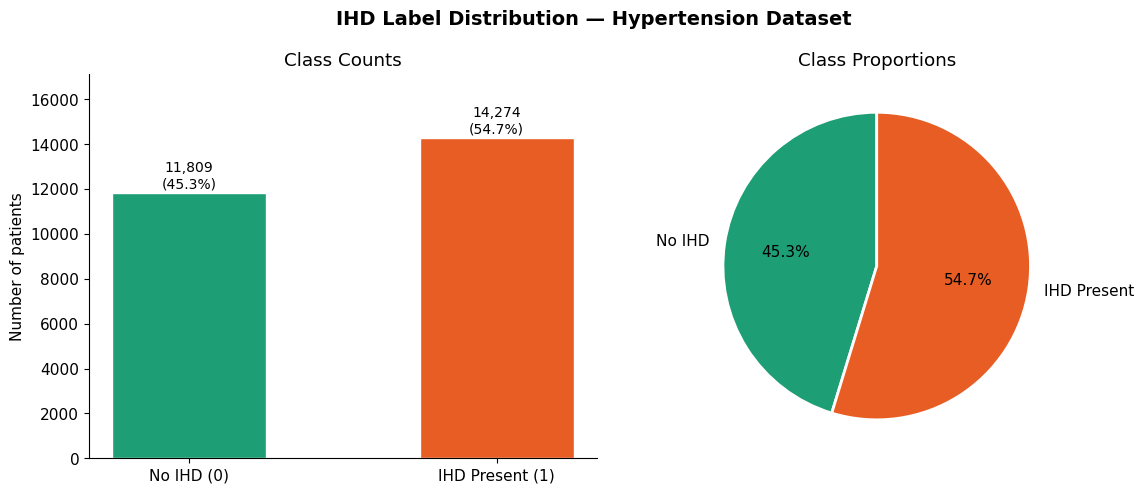

In [23]:
# Create a figure with 2 charts side by side
# figsize=(12, 5) means 12 inches wide, 5 inches tall
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Give the whole figure a title
fig.suptitle("IHD Label Distribution — Hypertension Dataset", fontsize=14, fontweight="bold")

# ── LEFT CHART: bar chart ───────────────────────────────────

counts = hypertension_df["target"].value_counts().sort_index()

# axes[0] refers to the left chart
bars = axes[0].bar(
    ["No IHD (0)", "IHD Present (1)"],   # x-axis labels
    counts.values,                         # heights of the bars
    color=["#1D9E75", "#E85D24"],          # teal for no IHD, coral for IHD
    width=0.5,
    edgecolor="white"
)

axes[0].set_title("Class Counts")
axes[0].set_ylabel("Number of patients")

# Add the count and percentage on top of each bar
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,   # x position = center of bar
        bar.get_height() + 100,               # y position = just above bar top
        f"{val:,}\n({val/len(hypertension_df)*100:.1f}%)",   # text to display
        ha="center", va="bottom", fontsize=10
    )

axes[0].set_ylim(0, max(counts.values) * 1.2)   # make y-axis a bit taller so text fits

# ── RIGHT CHART: pie chart ──────────────────────────────────

axes[1].pie(
    counts.values,
    labels=["No IHD", "IHD Present"],
    autopct="%1.1f%%",                          # show percentages with 1 decimal place
    colors=["#1D9E75", "#E85D24"],
    startangle=90,                              # start the first slice at the top
    wedgeprops={"edgecolor": "white", "linewidth": 2}   # white lines between slices
)
axes[1].set_title("Class Proportions")

plt.tight_layout()   # automatically adjusts spacing so nothing overlaps
plt.show()

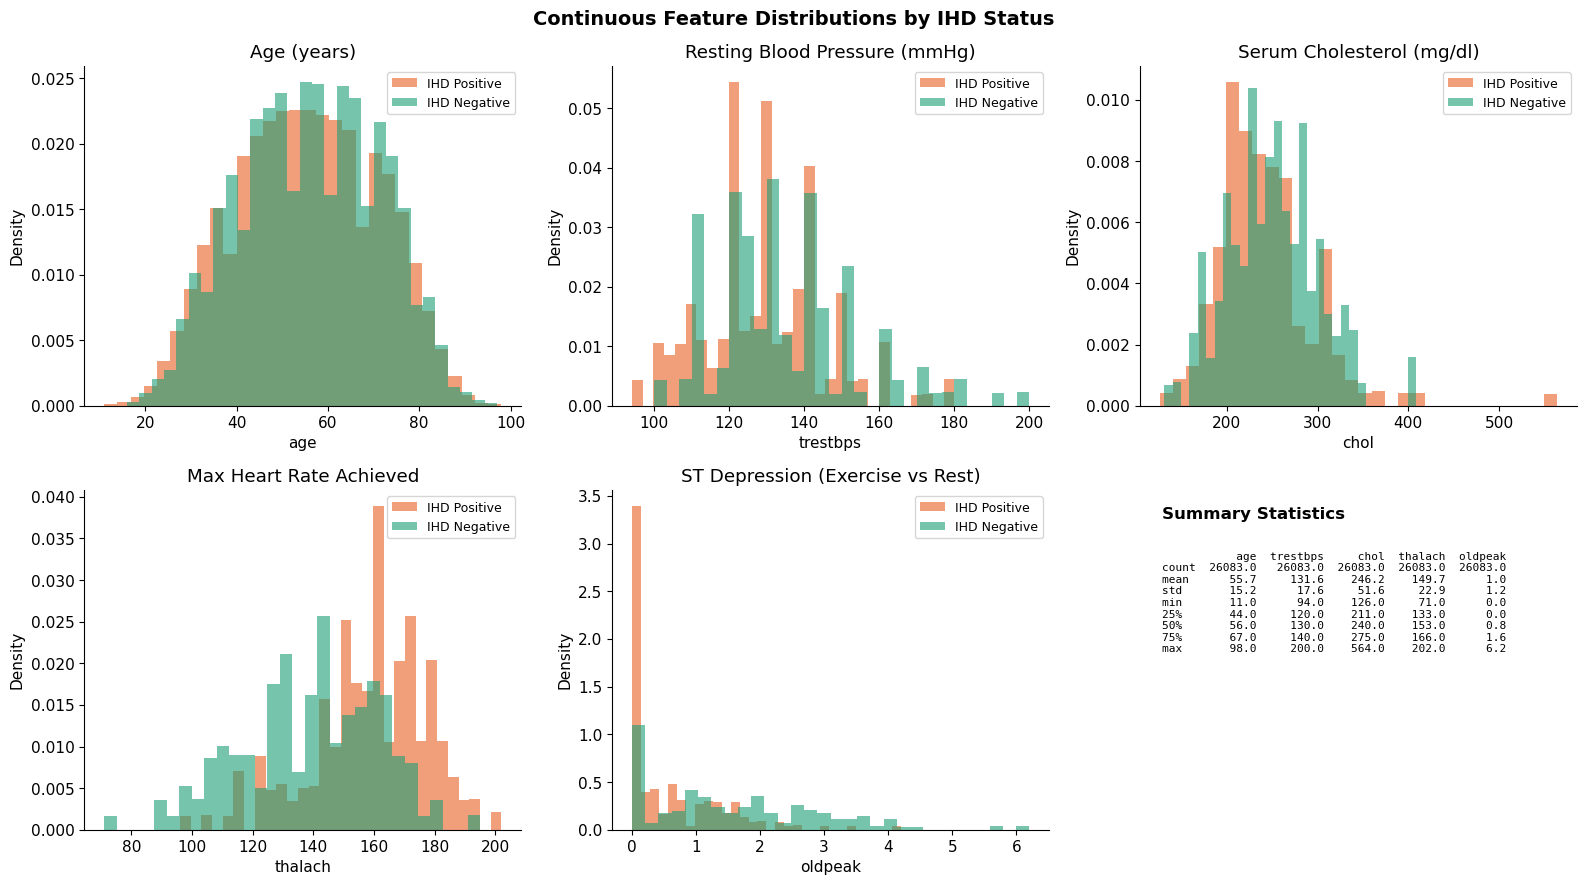

In [24]:
# These are the continuous (number) columns in the hypertension dataset
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Human-readable labels for the chart titles
feature_labels = {
    "age":      "Age (years)",
    "trestbps": "Resting Blood Pressure (mmHg)",
    "chol":     "Serum Cholesterol (mg/dl)",
    "thalach":  "Max Heart Rate Achieved",
    "oldpeak":  "ST Depression (Exercise vs Rest)"
}

# Create a grid of 2 rows and 3 columns = 6 subplots
# We only have 5 features so the 6th will be a summary table
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Continuous Feature Distributions by IHD Status", fontsize=14, fontweight="bold")

# .flatten() turns the 2D grid of axes into a simple list so we can loop through them
axes = axes.flatten()

# Add a readable IHD label column to the dataframe
hypertension_df["IHD"] = hypertension_df["target"].map({1: "IHD Positive", 0: "IHD Negative"})

for i, feature in enumerate(continuous_features):
    ax = axes[i]

    # Draw one histogram for IHD positive patients
    ihd_positive_values = hypertension_df[hypertension_df["IHD"] == "IHD Positive"][feature].dropna()
    ax.hist(ihd_positive_values, bins=30, alpha=0.6, color="#E85D24",
            label="IHD Positive", edgecolor="none", density=True)

    # Draw another histogram for IHD negative patients on the same chart
    ihd_negative_values = hypertension_df[hypertension_df["IHD"] == "IHD Negative"][feature].dropna()
    ax.hist(ihd_negative_values, bins=30, alpha=0.6, color="#1D9E75",
            label="IHD Negative", edgecolor="none", density=True)

    # density=True normalises the y-axis so both groups are comparable
    # even if one group has more patients than the other

    ax.set_title(feature_labels[feature])
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

# Use the 6th subplot (index 5) to show a summary table instead of a chart
axes[5].axis("off")   # turn off the chart axes for this subplot
summary_text = hypertension_df[continuous_features].describe().round(1).to_string()
axes[5].text(0.05, 0.95, "Summary Statistics", fontsize=12, fontweight="bold",
             transform=axes[5].transAxes, va="top")
axes[5].text(0.05, 0.82, summary_text, fontsize=8, transform=axes[5].transAxes,
             va="top", fontfamily="monospace")

plt.tight_layout()
plt.show()

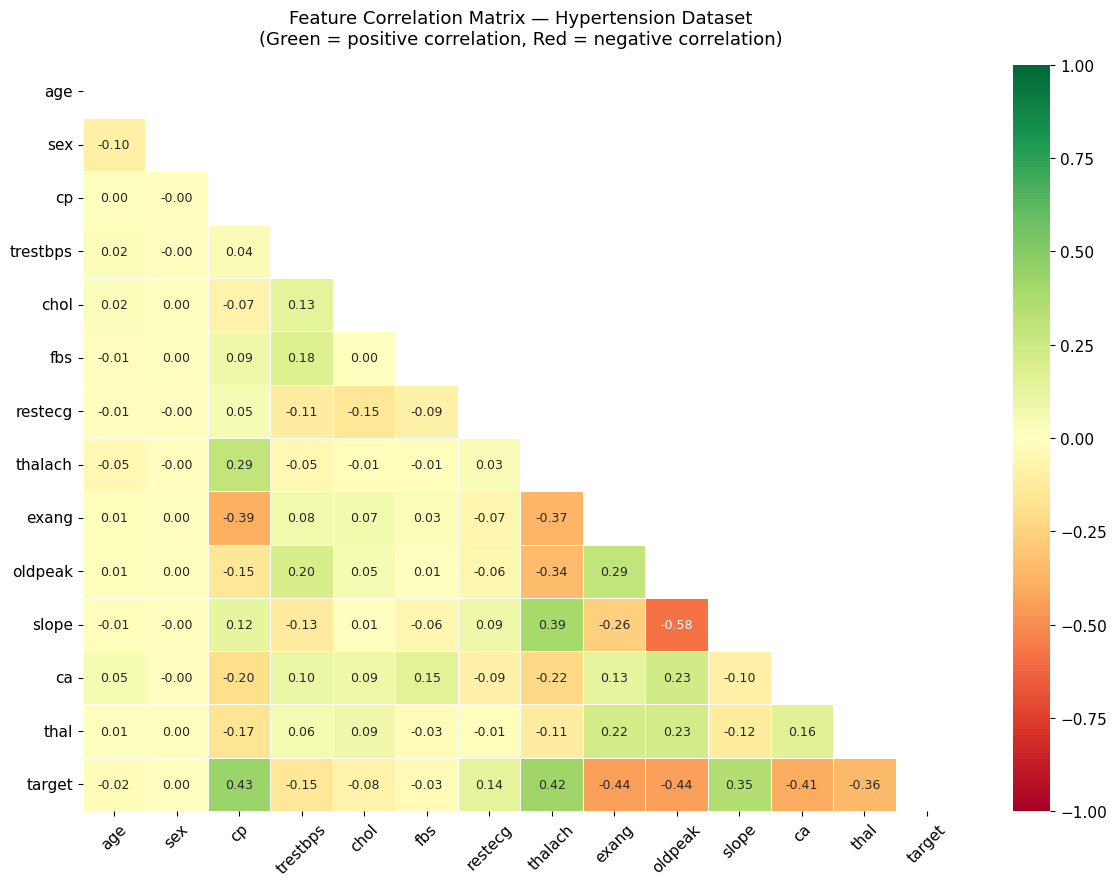


Feature correlations with IHD target (sorted strongest to weakest):
(Positive = feature goes up when IHD is present)
(Negative = feature goes down when IHD is present)

  oldpeak      -0.438  ↓
  exang        -0.438  ↓
  ca           -0.406  ↓
  thal         -0.358  ↓
  trestbps     -0.149  ↓
  chol         -0.082  ↓
  fbs          -0.034  ↓
  age          -0.024  ↓
  sex          +0.001  ↑
  restecg      +0.136  ↑
  slope        +0.350  ↑
  thalach      +0.419  ↑
  cp           +0.434  ↑


In [25]:
# Create the figure
fig, ax = plt.subplots(figsize=(12, 9))

# Remove the text IHD column before calculating correlations
# (correlation needs numbers only)
numeric_df = hypertension_df.drop(columns=["IHD"])

# .corr() calculates the correlation between every pair of columns
corr_matrix = numeric_df.corr()

# np.triu creates a mask (like a stencil) to hide the upper triangle of the heatmap
# We only show the lower triangle to avoid showing every pair twice
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
# annot=True shows the actual numbers inside each cell
# fmt=".2f" formats numbers to 2 decimal places
# cmap="RdYlGn" means red for negative, yellow for zero, green for positive
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 9}
)

ax.set_title(
    "Feature Correlation Matrix — Hypertension Dataset\n"
    "(Green = positive correlation, Red = negative correlation)",
    fontsize=13, pad=15
)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Also print the correlations with target sorted from strongest to weakest
print("\nFeature correlations with IHD target (sorted strongest to weakest):")
print("(Positive = feature goes up when IHD is present)")
print("(Negative = feature goes down when IHD is present)")
print()
corr_with_target = corr_matrix["target"].drop("target").sort_values()
for feature, corr_value in corr_with_target.items():
    direction = "↑" if corr_value > 0 else "↓"
    print(f"  {feature:<12} {corr_value:+.3f}  {direction}")

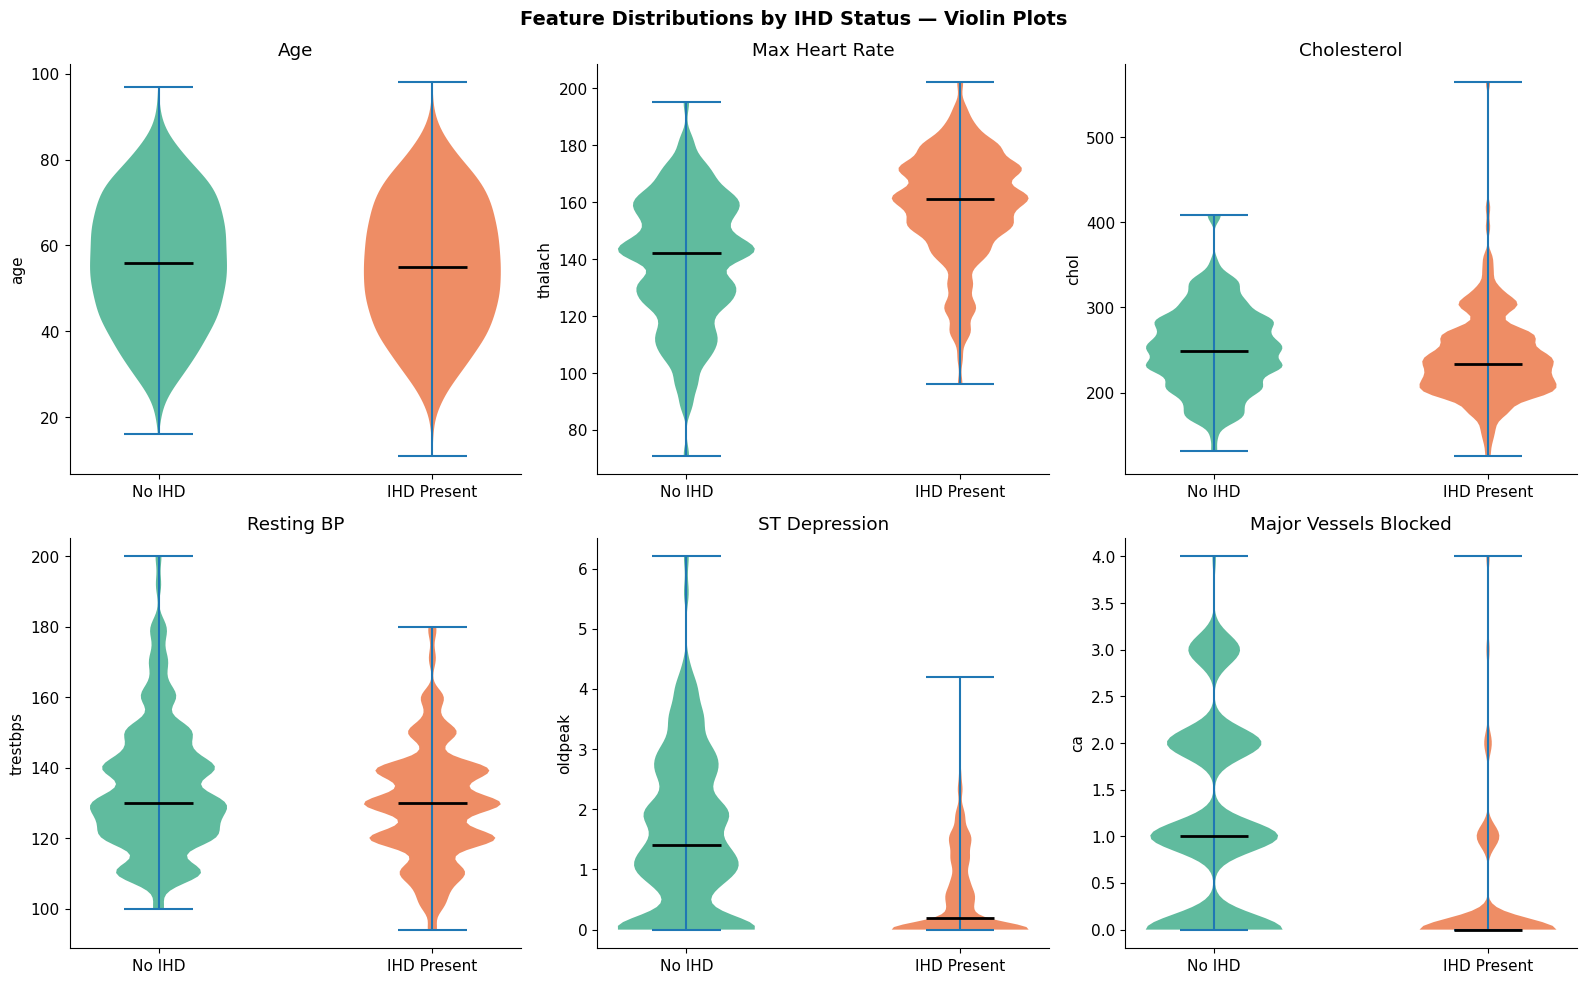

In [27]:
# Features we want to compare between IHD and non-IHD patients
violin_features = ["age", "thalach", "chol", "trestbps", "oldpeak", "ca"]
violin_labels   = {
    "age":      "Age",
    "thalach":  "Max Heart Rate",
    "chol":     "Cholesterol",
    "trestbps": "Resting BP",
    "oldpeak":  "ST Depression",
    "ca":       "Major Vessels Blocked"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Feature Distributions by IHD Status — Violin Plots", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, feature in enumerate(violin_features):
    ax = axes[i]

    # Separate the data for IHD positive and negative patients
    no_ihd_values  = hypertension_df[hypertension_df["IHD"] == "IHD Negative"][feature].dropna().values
    yes_ihd_values = hypertension_df[hypertension_df["IHD"] == "IHD Positive"][feature].dropna().values

    # violinplot needs a list of arrays — one array per violin
    parts = ax.violinplot(
        [no_ihd_values, yes_ihd_values],
        positions=[0, 1],         # where on the x-axis to draw each violin
        showmedians=True,         # show the median line inside each violin
        showextrema=True          # show the min/max lines
    )

    # Colour the violin bodies
    # parts["bodies"] is a list of the two violin shapes
    for j, body in enumerate(parts["bodies"]):
        body.set_facecolor(["#1D9E75", "#E85D24"][j])
        body.set_alpha(0.7)

    # Make the median line black and thick so it's easy to see
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No IHD", "IHD Present"])
    ax.set_title(violin_labels[feature])
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

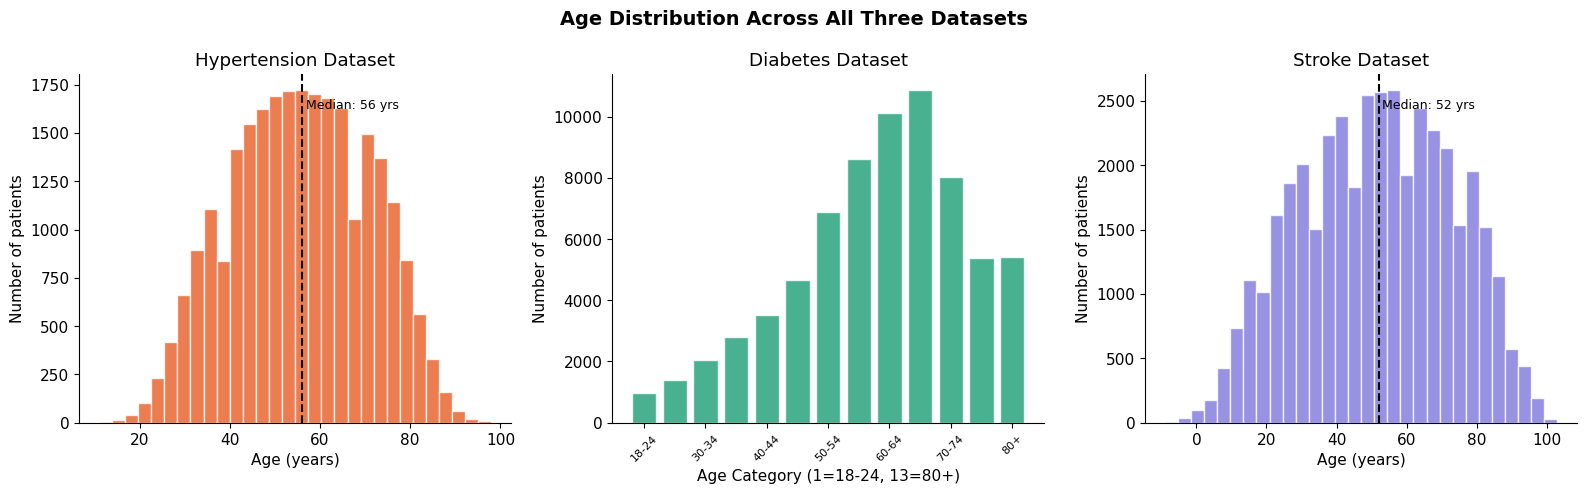

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Age Distribution Across All Three Datasets", fontsize=14, fontweight="bold")

# ── LEFT: Hypertension dataset ──────────────────────────────
# This dataset has actual age in years as a number
axes[0].hist(hypertension_df["age"].dropna(), bins=30,
             color="#E85D24", alpha=0.8, edgecolor="white")
axes[0].set_title("Hypertension Dataset")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Number of patients")

# Add a vertical dashed line showing the median age
median_age = hypertension_df["age"].median()
axes[0].axvline(median_age, color="black", linestyle="--", linewidth=1.5)
axes[0].text(median_age + 1, axes[0].get_ylim()[1] * 0.9,
             f"Median: {median_age:.0f} yrs", fontsize=9)

# ── MIDDLE: Diabetes dataset ────────────────────────────────
# This dataset stores age as categories: 1=18-24, 2=25-29, ..., 13=80+
# We can't plot raw age categories as a histogram — we use a bar chart instead
age_counts = diabetes_df["Age"].value_counts().sort_index()

# Map the category numbers to readable age labels
age_label_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44",
    6: "45-49", 7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69",
    11: "70-74", 12: "75-79", 13: "80+"
}

axes[1].bar(age_counts.index, age_counts.values, color="#1D9E75", alpha=0.8, edgecolor="white")
axes[1].set_title("Diabetes Dataset")
axes[1].set_xlabel("Age Category (1=18-24, 13=80+)")
axes[1].set_ylabel("Number of patients")

# Only show every other label on the x-axis so they don't overlap
tick_positions = [1, 3, 5, 7, 9, 11, 13]
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels([age_label_map[i] for i in tick_positions], rotation=45, fontsize=8)

# ── RIGHT: Stroke dataset ───────────────────────────────────
axes[2].hist(stroke_df["age"].dropna(), bins=30,
             color="#7F77DD", alpha=0.8, edgecolor="white")
axes[2].set_title("Stroke Dataset")
axes[2].set_xlabel("Age (years)")
axes[2].set_ylabel("Number of patients")

median_stroke_age = stroke_df["age"].median()
axes[2].axvline(median_stroke_age, color="black", linestyle="--", linewidth=1.5)
axes[2].text(median_stroke_age + 1, axes[2].get_ylim()[1] * 0.9,
             f"Median: {median_stroke_age:.0f} yrs", fontsize=9)

plt.tight_layout()
plt.show()

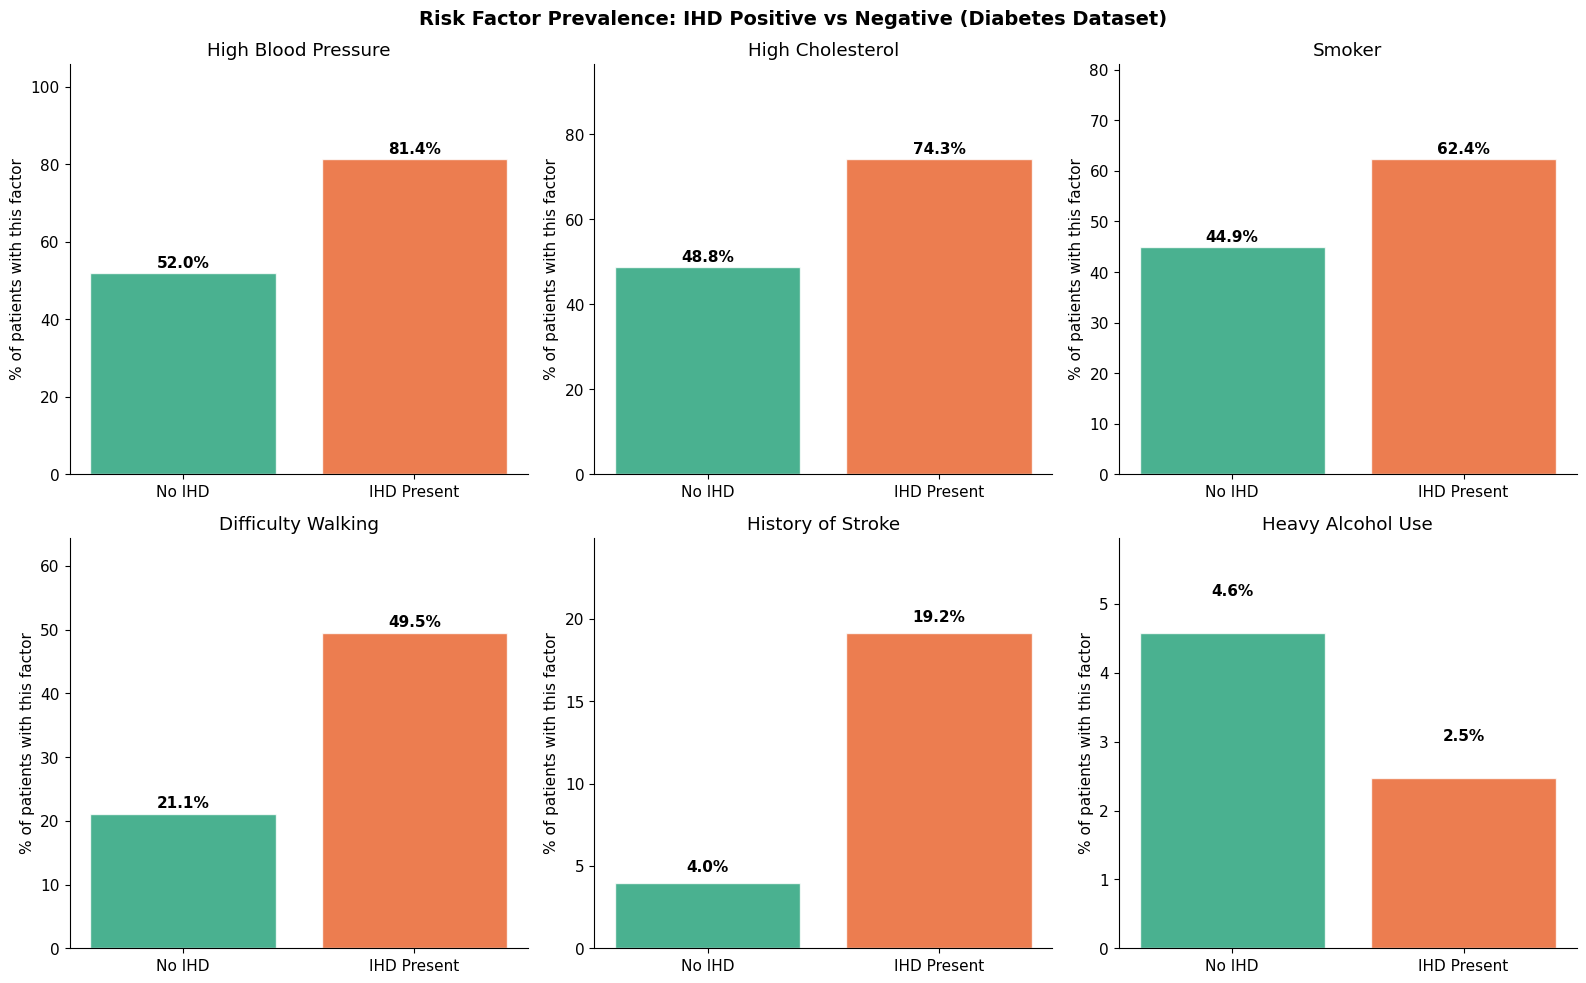

In [30]:
# Split the diabetes dataset into those with and without heart disease
ihd_positive_diabetes = diabetes_df[diabetes_df["HeartDiseaseorAttack"] == 1]
ihd_negative_diabetes = diabetes_df[diabetes_df["HeartDiseaseorAttack"] == 0]

# The risk factors we want to compare
risk_features = ["HighBP", "HighChol", "Smoker", "DiffWalk", "Stroke", "HvyAlcoholConsump"]
risk_labels   = {
    "HighBP":            "High Blood Pressure",
    "HighChol":          "High Cholesterol",
    "Smoker":            "Smoker",
    "DiffWalk":          "Difficulty Walking",
    "Stroke":            "History of Stroke",
    "HvyAlcoholConsump": "Heavy Alcohol Use"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Risk Factor Prevalence: IHD Positive vs Negative (Diabetes Dataset)",
    fontsize=14, fontweight="bold"
)
axes = axes.flatten()

for i, feature in enumerate(risk_features):
    ax = axes[i]

    # .mean() on a 0/1 column gives you the proportion (fraction) with value = 1
    # Multiply by 100 to get percentage
    no_ihd_pct  = ihd_negative_diabetes[feature].mean() * 100
    yes_ihd_pct = ihd_positive_diabetes[feature].mean() * 100

    bars = ax.bar(
        ["No IHD", "IHD Present"],
        [no_ihd_pct, yes_ihd_pct],
        color=["#1D9E75", "#E85D24"],
        alpha=0.8,
        edgecolor="white"
    )

    # Add percentage labels on top of each bar
    for bar, val in zip(bars, [no_ihd_pct, yes_ihd_pct]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_title(risk_labels[feature])
    ax.set_ylabel("% of patients with this factor")
    ax.set_ylim(0, max(no_ihd_pct, yes_ihd_pct) * 1.3)

plt.tight_layout()
plt.show()

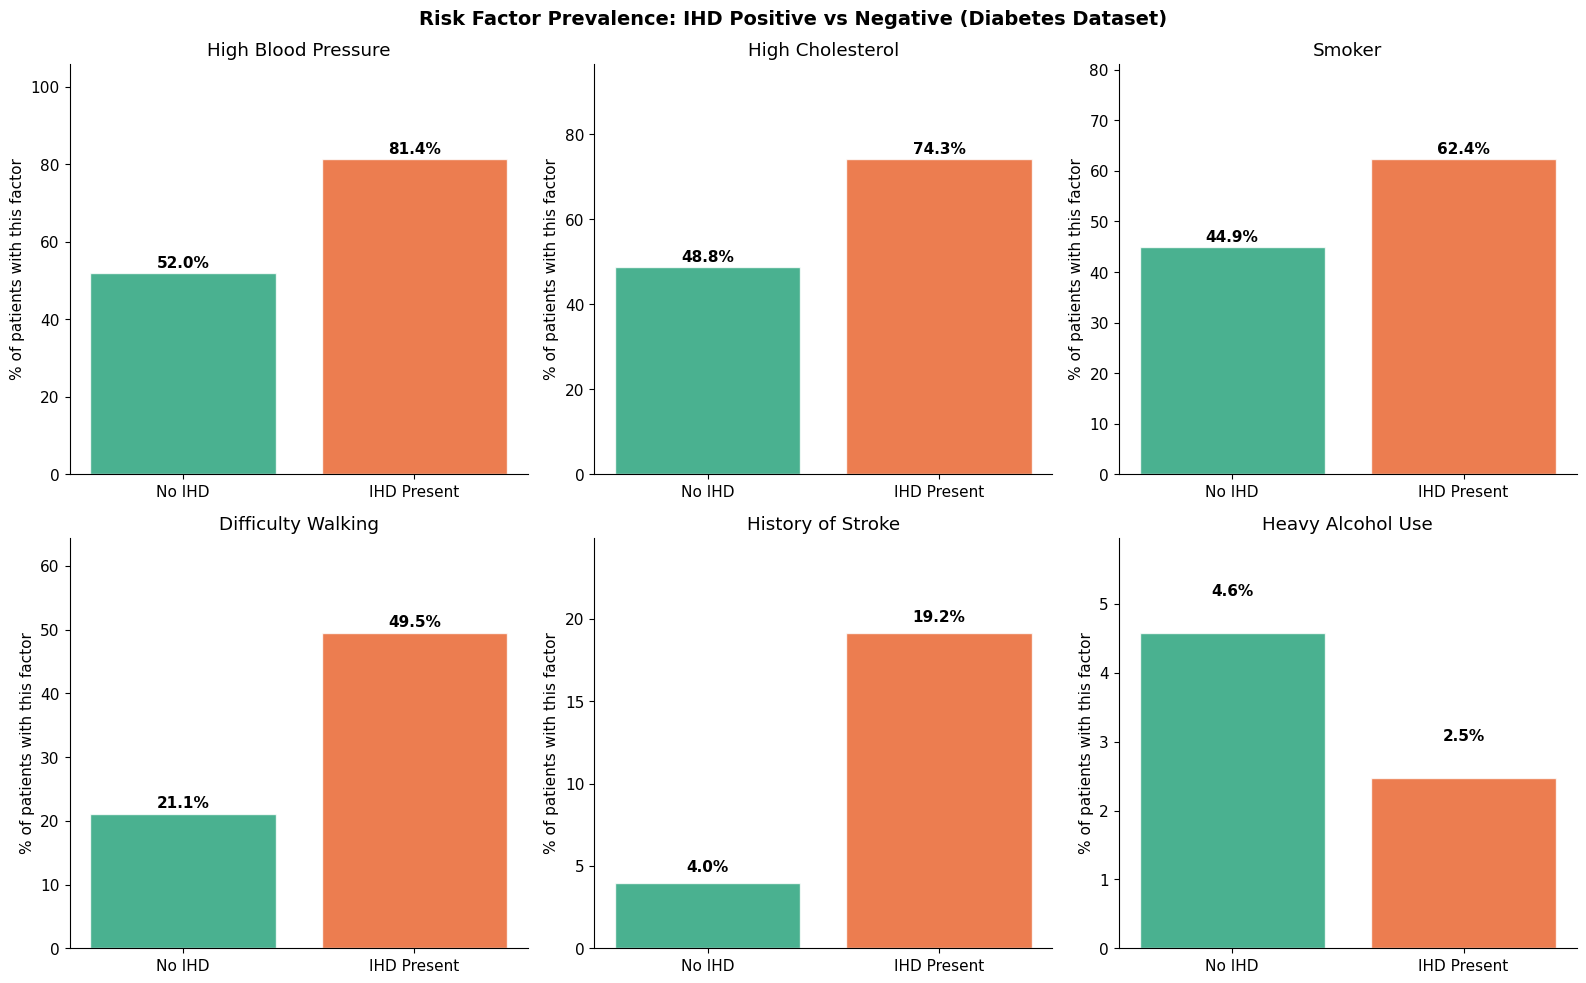

In [31]:
# Split the diabetes dataset into those with and without heart disease
ihd_positive_diabetes = diabetes_df[diabetes_df["HeartDiseaseorAttack"] == 1]
ihd_negative_diabetes = diabetes_df[diabetes_df["HeartDiseaseorAttack"] == 0]

# The risk factors we want to compare
risk_features = ["HighBP", "HighChol", "Smoker", "DiffWalk", "Stroke", "HvyAlcoholConsump"]
risk_labels   = {
    "HighBP":            "High Blood Pressure",
    "HighChol":          "High Cholesterol",
    "Smoker":            "Smoker",
    "DiffWalk":          "Difficulty Walking",
    "Stroke":            "History of Stroke",
    "HvyAlcoholConsump": "Heavy Alcohol Use"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Risk Factor Prevalence: IHD Positive vs Negative (Diabetes Dataset)",
    fontsize=14, fontweight="bold"
)
axes = axes.flatten()

for i, feature in enumerate(risk_features):
    ax = axes[i]

    # .mean() on a 0/1 column gives you the proportion (fraction) with value = 1
    # Multiply by 100 to get percentage
    no_ihd_pct  = ihd_negative_diabetes[feature].mean() * 100
    yes_ihd_pct = ihd_positive_diabetes[feature].mean() * 100

    bars = ax.bar(
        ["No IHD", "IHD Present"],
        [no_ihd_pct, yes_ihd_pct],
        color=["#1D9E75", "#E85D24"],
        alpha=0.8,
        edgecolor="white"
    )

    # Add percentage labels on top of each bar
    for bar, val in zip(bars, [no_ihd_pct, yes_ihd_pct]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_title(risk_labels[feature])
    ax.set_ylabel("% of patients with this factor")
    ax.set_ylim(0, max(no_ihd_pct, yes_ihd_pct) * 1.3)

plt.tight_layout()
plt.show()

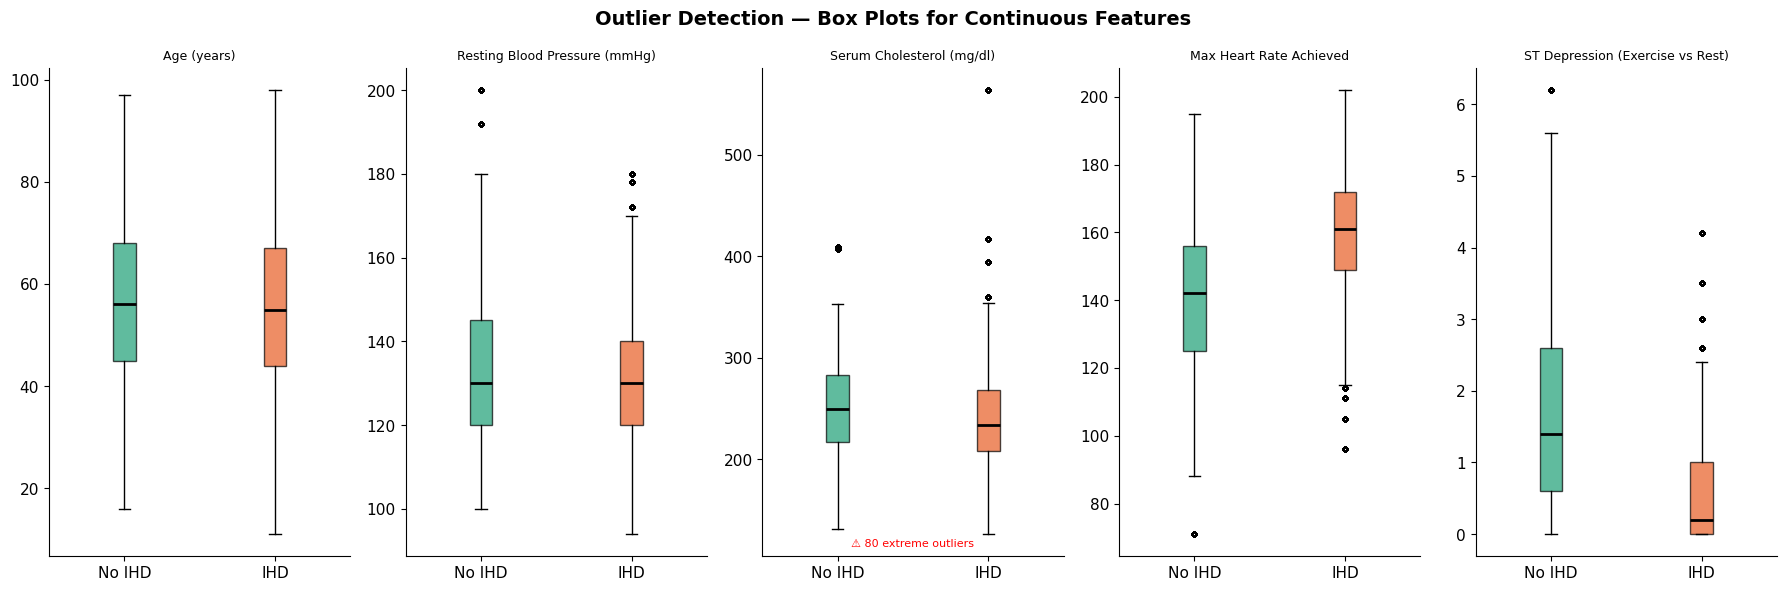

In [32]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle("Outlier Detection — Box Plots for Continuous Features", fontsize=14, fontweight="bold")

for i, feature in enumerate(continuous_features):
    ax = axes[i]

    # Separate into two groups for side-by-side box plots
    no_ihd_values  = hypertension_df[hypertension_df["target"] == 0][feature].dropna()
    yes_ihd_values = hypertension_df[hypertension_df["target"] == 1][feature].dropna()

    # patch_artist=True fills the boxes with colour instead of leaving them empty
    bp = ax.boxplot(
        [no_ihd_values, yes_ihd_values],
        labels=["No IHD", "IHD"],
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2},
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4}
    )

    # Colour the boxes
    bp["boxes"][0].set_facecolor("#1D9E75")
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#E85D24")
    bp["boxes"][1].set_alpha(0.7)

    ax.set_title(feature_labels[feature], fontsize=9)

    # Count extreme outliers using the IQR method:
    # Anything below Q1 - 3*IQR or above Q3 + 3*IQR is an extreme outlier
    all_values = hypertension_df[feature].dropna()
    q1 = np.percentile(all_values, 25)    # 25th percentile
    q3 = np.percentile(all_values, 75)    # 75th percentile
    iqr = q3 - q1                          # interquartile range

    extreme_low  = (all_values < (q1 - 3 * iqr)).sum()
    extreme_high = (all_values > (q3 + 3 * iqr)).sum()
    total_outliers = extreme_low + extreme_high

    if total_outliers > 0:
        ax.text(0.5, 0.02, f"⚠ {total_outliers} extreme outliers",
                transform=ax.transAxes, ha="center", fontsize=8, color="red")

plt.tight_layout()
plt.show()

In [33]:
# Check how many rows have zero cholesterol
zero_chol_count = (hypertension_df["chol"] == 0).sum()
print(f"Patients with cholesterol = 0 (data error): {zero_chol_count}")

# Calculate median cholesterol ONLY from rows where chol > 0
# We exclude the zero values from the calculation
median_chol = hypertension_df[hypertension_df["chol"] > 0]["chol"].median()
print(f"Median cholesterol (excluding zeros): {median_chol:.0f} mg/dl")

# Replace all zero cholesterol values with the median
# loc[] lets us select specific rows and columns to change
hypertension_df.loc[hypertension_df["chol"] == 0, "chol"] = median_chol

print(f"✓ Replaced {zero_chol_count} zero values with {median_chol:.0f}")
print(f"New minimum cholesterol: {hypertension_df['chol'].min():.0f}")

Patients with cholesterol = 0 (data error): 0
Median cholesterol (excluding zeros): 240 mg/dl
✓ Replaced 0 zero values with 240
New minimum cholesterol: 126


In [34]:
# Fix missing sex values in stroke dataset (only 3 rows)
stroke_df["sex"].fillna(stroke_df["sex"].mode()[0], inplace=True)
print(f"Sex missing values after fix: {stroke_df['sex'].isnull().sum()}")

# Fix missing BMI values
bmi_missing = stroke_df["bmi"].isnull().sum()
print(f"BMI missing values found: {bmi_missing}")

if bmi_missing > 0:
    median_bmi = stroke_df["bmi"].median()
    stroke_df["bmi"].fillna(median_bmi, inplace=True)
    print(f"✓ Replaced {bmi_missing} missing BMI values with median ({median_bmi:.1f})")

print(f"\nAll missing values after cleaning:")
print(f"  Hypertension: {hypertension_df.isnull().sum().sum()}")
print(f"  Diabetes    : {diabetes_df.isnull().sum().sum()}")
print(f"  Stroke      : {stroke_df.isnull().sum().sum()}")

Sex missing values after fix: 0
BMI missing values found: 0

All missing values after cleaning:
  Hypertension: 0
  Diabetes    : 0
  Stroke      : 0


In [35]:
# Copy the hypertension dataframe so we don't accidentally change the original
# .copy() is important — without it, changes to df would also change hypertension_df
df = hypertension_df.copy()

# Rename "target" to "ihd_label" so it's clear what this column means
df.rename(columns={"target": "ihd_label"}, inplace=True)

# Remove the text "IHD" column we added earlier — we don't need it anymore
df.drop(columns=["IHD"], inplace=True)

print(f"Working dataframe shape: {df.shape}")
print(f"\nColumns:")
for col in df.columns:
    print(f"  • {col}")
print(f"\nLabel distribution: {dict(df['ihd_label'].value_counts())}")

Working dataframe shape: (26083, 14)

Columns:
  • age
  • sex
  • cp
  • trestbps
  • chol
  • fbs
  • restecg
  • thalach
  • exang
  • oldpeak
  • slope
  • ca
  • thal
  • ihd_label

Label distribution: {1: np.int64(14274), 0: np.int64(11809)}


In [36]:
# pd.cut() divides a continuous variable into bins (groups)
# bins=[0, 40, 55, 65, 100] means: group ages into < 40, 40-55, 55-65, 65+
# labels=[0, 1, 2, 3] assigns numbers to each group (models need numbers not text)

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 55, 65, 100],
    labels=[0, 1, 2, 3]
).astype(float)

# Let's verify it looks right
print("Age group distribution:")
age_group_counts = df["age_group"].value_counts().sort_index()
group_labels = {0.0: "<40 years", 1.0: "40-55 years", 2.0: "55-65 years", 3.0: "65+ years"}
for group, count in age_group_counts.items():
    print(f"  Group {group:.0f} ({group_labels[group]}): {count:,} patients")

Age group distribution:
  Group 0 (<40 years): 4,768 patients
  Group 1 (40-55 years): 8,121 patients
  Group 2 (55-65 years): 5,622 patients
  Group 3 (65+ years): 7,572 patients


In [37]:
# (df["trestbps"] >= 140) creates a column of True/False values
# .astype(int) converts True→1, False→0 so the model can use it

df["high_bp_flag"] = (df["trestbps"] >= 140).astype(int)

# Same for cholesterol
df["high_chol_flag"] = (df["chol"] >= 240).astype(int)

# Check: what percentage of patients hit each threshold?
bp_pct   = df["high_bp_flag"].mean() * 100
chol_pct = df["high_chol_flag"].mean() * 100

print(f"Patients with high BP (≥140 mmHg)      : {df['high_bp_flag'].sum():,} ({bp_pct:.1f}%)")
print(f"Patients with high cholesterol (≥240)  : {df['high_chol_flag'].sum():,} ({chol_pct:.1f}%)")

Patients with high BP (≥140 mmHg)      : 8,430 (32.3%)
Patients with high cholesterol (≥240)  : 13,344 (51.2%)


In [38]:
# Formula: age-predicted max HR = 220 - age
# Heart rate reserve = age-predicted max HR - actual max HR (thalach)
# Lower values = worse cardiac performance = higher IHD risk

df["hr_reserve"] = (220 - df["age"]) - df["thalach"]

# Let's see the average for each IHD group to confirm the logic makes sense
print("Average heart rate reserve by IHD status:")
reserve_by_ihd = df.groupby("ihd_label")["hr_reserve"].mean()
for label, value in reserve_by_ihd.items():
    group_name = "IHD Present" if label == 1 else "No IHD    "
    print(f"  {group_name}: {value:.1f}")
print("\n(Higher reserve in IHD patients = heart couldn't keep up = confirms feature makes sense)")

Average heart rate reserve by IHD status:
  No IHD    : 24.8
  IHD Present: 6.3

(Higher reserve in IHD patients = heart couldn't keep up = confirms feature makes sense)


In [39]:
# ST depression > 2 = clinically significant finding
df["st_depression_severe"] = (df["oldpeak"] > 2).astype(int)

# Combination feature: angina + ST depression occurring together
# This uses a logical AND — both conditions must be true
df["angina_st_combo"] = (
    (df["exang"] == 1) &      # exercise-induced angina = yes
    (df["oldpeak"] > 0)       # AND any amount of ST depression
).astype(int)

print(f"Patients with severe ST depression (>2)  : {df['st_depression_severe'].sum():,}")
print(f"Patients with angina + ST depression combo: {df['angina_st_combo'].sum():,}")

# Check if the combo feature is actually different between IHD groups
print("\nAngina + ST combo prevalence by IHD status:")
combo_by_ihd = df.groupby("ihd_label")["angina_st_combo"].mean() * 100
for label, pct in combo_by_ihd.items():
    print(f"  {'IHD Present' if label==1 else 'No IHD    '}: {pct:.1f}% have this combination")

Patients with severe ST depression (>2)  : 4,346
Patients with angina + ST depression combo: 6,846

Angina + ST combo prevalence by IHD status:
  No IHD    : 47.8% have this combination
  IHD Present: 8.4% have this combination


In [40]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler scales values to be between 0 and 1
# Formula: (value - minimum) / (maximum - minimum)
# A value at the minimum becomes 0, at the maximum becomes 1

scaler_temp = MinMaxScaler()

# We scale trestbps and chol together
# fit_transform learns the min/max AND applies the scaling in one step
scaled_values = scaler_temp.fit_transform(df[["trestbps", "chol"]])

# .mean(axis=1) averages the two scaled values for each patient (across columns)
df["metabolic_risk_score"] = scaled_values.mean(axis=1)

print("Metabolic risk score statistics:")
print(f"  Minimum : {df['metabolic_risk_score'].min():.3f}")
print(f"  Maximum : {df['metabolic_risk_score'].max():.3f}")
print(f"  Average : {df['metabolic_risk_score'].mean():.3f}")
print("\nMetabolic risk score by IHD status:")
print(df.groupby("ihd_label")["metabolic_risk_score"].mean().round(3))

Metabolic risk score statistics:
  Minimum : 0.083
  Maximum : 0.685
  Average : 0.315

Metabolic risk score by IHD status:
ihd_label
0    0.333
1    0.299
Name: metabolic_risk_score, dtype: float64


In [41]:
# Feature 8: vessel × thalassemia interaction
# ca = 0,1,2,3 (number of blocked vessels)
# thal = 3 means reversable defect (most serious)
# When both are present together, risk is elevated

df["vessel_thal_risk"] = df["ca"] * (df["thal"] == 3).astype(int)

# Feature 9: age-sex risk threshold
# Medical guidelines say IHD risk significantly increases at:
#   - Age 45+ for men
#   - Age 55+ for women

df["age_sex_risk"] = (
    ((df["sex"] == 1) & (df["age"] >= 45)) |   # male aged 45 or older
    ((df["sex"] == 0) & (df["age"] >= 55))      # female aged 55 or older
).astype(int)

print("Feature distributions:")
print(f"  vessel_thal_risk > 0 : {(df['vessel_thal_risk'] > 0).sum():,} patients")
print(f"  age_sex_risk = 1     : {df['age_sex_risk'].sum():,} patients ({df['age_sex_risk'].mean()*100:.1f}%)")

print("\nAge-sex risk by IHD group:")
print(df.groupby("ihd_label")["age_sex_risk"].mean().round(3) * 100)
print("(percentage of each group that crosses the age threshold)")

Feature distributions:
  vessel_thal_risk > 0 : 5,718 patients
  age_sex_risk = 1     : 16,591 patients (63.6%)

Age-sex risk by IHD group:
ihd_label
0    64.7
1    62.7
Name: age_sex_risk, dtype: float64
(percentage of each group that crosses the age threshold)


In [42]:
# pd.get_dummies() converts a categorical column into multiple 0/1 columns
# prefix="cp" means the new columns will be named cp_0, cp_1, cp_2, cp_3

cp_dummies = pd.get_dummies(df["cp"], prefix="cp", drop_first=False)
print(f"cp column converted into {len(cp_dummies.columns)} new columns: {list(cp_dummies.columns)}")
print(cp_dummies.head(3))

# pd.concat() joins the new columns onto our main dataframe
df = pd.concat([df, cp_dummies], axis=1)   # axis=1 means add as new columns (not rows)

# Drop the original cp column — we no longer need it
df.drop(columns=["cp"], inplace=True)

# Same process for restecg (resting ECG result)
restecg_dummies = pd.get_dummies(df["restecg"], prefix="restecg", drop_first=False)
print(f"\nrestecg converted into: {list(restecg_dummies.columns)}")

df = pd.concat([df, restecg_dummies], axis=1)
df.drop(columns=["restecg"], inplace=True)

# Convert any True/False columns to 0/1 integers
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"\nFinal dataframe shape: {df.shape}")
print(f"All columns: {list(df.columns)}")

cp column converted into 4 new columns: ['cp_0', 'cp_1', 'cp_2', 'cp_3']
    cp_0   cp_1   cp_2   cp_3
0  False  False  False   True
1  False  False   True  False
2  False   True  False  False

restecg converted into: ['restecg_0', 'restecg_1', 'restecg_2']

Final dataframe shape: (26083, 28)
All columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'ihd_label', 'age_group', 'high_bp_flag', 'high_chol_flag', 'hr_reserve', 'st_depression_severe', 'angina_st_combo', 'metabolic_risk_score', 'vessel_thal_risk', 'age_sex_risk', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2']


In [43]:
import os

# Create the output folders if they don't exist
os.makedirs("outputs/processed", exist_ok=True)
os.makedirs("outputs/models",    exist_ok=True)
os.makedirs("outputs/evaluation",exist_ok=True)

# Move the label column to the end (good practice — targets usually go last)
label_col = df.pop("ihd_label")
df["ihd_label"] = label_col

# Save to CSV
df.to_csv("outputs/processed/ihd_features_final.csv", index=False)

# index=False means don't save the row numbers (they're useless in the file)

print(f"✓ Saved to: outputs/processed/ihd_features_final.csv")
print(f"  Shape: {df.shape}")
print(f"\nFinal feature list ({len(df.columns)-1} features + 1 label):")
for i, col in enumerate(df.columns):
    marker = " ← LABEL" if col == "ihd_label" else ""
    print(f"  {i+1:2d}. {col}{marker}")

✓ Saved to: outputs/processed/ihd_features_final.csv
  Shape: (26083, 28)

Final feature list (27 features + 1 label):
   1. age
   2. sex
   3. trestbps
   4. chol
   5. fbs
   6. thalach
   7. exang
   8. oldpeak
   9. slope
  10. ca
  11. thal
  12. age_group
  13. high_bp_flag
  14. high_chol_flag
  15. hr_reserve
  16. st_depression_severe
  17. angina_st_combo
  18. metabolic_risk_score
  19. vessel_thal_risk
  20. age_sex_risk
  21. cp_0
  22. cp_1
  23. cp_2
  24. cp_3
  25. restecg_0
  26. restecg_1
  27. restecg_2
  28. ihd_label ← LABEL


In [44]:
from sklearn.model_selection import train_test_split

# Load our cleaned, engineered dataset
df_model = pd.read_csv("outputs/processed/ihd_features_final.csv")

# X = features (all columns except the label)
# y = label (the thing we're predicting)
X = df_model.drop(columns=["ihd_label"])
y = df_model["ihd_label"]

print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution  : {dict(y.value_counts())}")

# Split into 80% training and 20% testing
# random_state=42 makes the split reproducible — you'll always get the same split
# stratify=y ensures both splits have the same ratio of IHD/non-IHD patients
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nAfter splitting:")
print(f"  Training set : {X_train.shape[0]:,} patients (80%)")
print(f"  Test set     : {X_test.shape[0]:,} patients (20%)")
print(f"  Train IHD rate: {y_train.mean():.3f}")
print(f"  Test  IHD rate: {y_test.mean():.3f}  ← should be similar to train (stratified)")

Feature matrix shape: (26083, 27)
Label distribution  : {1: np.int64(14274), 0: np.int64(11809)}

After splitting:
  Training set : 20,866 patients (80%)
  Test set     : 5,217 patients (20%)
  Train IHD rate: 0.547
  Test  IHD rate: 0.547  ← should be similar to train (stratified)


In [45]:
from sklearn.preprocessing import StandardScaler

# StandardScaler converts every feature so that:
# - Mean becomes 0
# - Standard deviation becomes 1
# Formula for each value: (value - mean) / standard_deviation

scaler = StandardScaler()

# fit_transform on TRAINING data:
# "fit" = learn the mean and std from training data
# "transform" = apply the scaling
X_train_scaled = scaler.fit_transform(X_train)

# transform only on TEST data:
# We use the SAME mean and std we learned from training
# We do NOT refit on test data — that would be cheating (data leakage)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames so feature names are preserved
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

# Save the scaler — we'll need it later in the app
import pickle
with open("outputs/models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# "wb" = write binary mode (required for pickle files)
print("✓ Scaler fitted on training data and saved")
print(f"  Example: 'age' mean={scaler.mean_[0]:.1f}, std={scaler.scale_[0]:.1f}")

✓ Scaler fitted on training data and saved
  Example: 'age' mean=55.7, std=15.2


In [46]:
from sklearn.preprocessing import StandardScaler

# StandardScaler converts every feature so that:
# - Mean becomes 0
# - Standard deviation becomes 1
# Formula for each value: (value - mean) / standard_deviation

scaler = StandardScaler()

# fit_transform on TRAINING data:
# "fit" = learn the mean and std from training data
# "transform" = apply the scaling
X_train_scaled = scaler.fit_transform(X_train)

# transform only on TEST data:
# We use the SAME mean and std we learned from training
# We do NOT refit on test data — that would be cheating (data leakage)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames so feature names are preserved
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

# Save the scaler — we'll need it later in the app
import pickle
with open("outputs/models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# "wb" = write binary mode (required for pickle files)
print("✓ Scaler fitted on training data and saved")
print(f"  Example: 'age' mean={scaler.mean_[0]:.1f}, std={scaler.scale_[0]:.1f}")

✓ Scaler fitted on training data and saved
  Example: 'age' mean=55.7, std=15.2


In [47]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not installed — run: pip install xgboost")

RANDOM_STATE = 42

# Define each model with sensible starting settings
models = {

    # LOGISTIC REGRESSION: the simplest model — always start here as a baseline
    # max_iter=1000 gives it enough time to find a solution
    # class_weight="balanced" handles any mild class imbalance automatically
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),

    # RANDOM FOREST: builds 200 decision trees, each on a random subset of data
    # then takes a majority vote across all trees
    # n_jobs=-1 means use all available CPU cores to speed things up
    "Random Forest": RandomForestClassifier(
        n_estimators=200,        # number of trees
        min_samples_split=5,     # minimum patients needed to split a node
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),

    # GRADIENT BOOSTING: builds trees one at a time
    # each new tree focuses on correcting the mistakes of the previous ones
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,       # how much each new tree corrects the previous (smaller = more careful)
        max_depth=4,             # how deep each tree can grow
        random_state=RANDOM_STATE
    ),

    # MLP NEURAL NETWORK: a 3-layer network
    # (128 neurons) → (64 neurons) → (32 neurons) → output
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True,     # stops training if performance stops improving
        validation_fraction=0.1
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0
    )

print(f"\n{len(models)} models ready to train:")
for name in models:
    print(f"  • {name}")

✓ XGBoost available

5 models ready to train:
  • Logistic Regression
  • Random Forest
  • Gradient Boosting
  • MLP Neural Network
  • XGBoost


In [48]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# StratifiedKFold ensures each fold has the same IHD ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []   # we'll collect results from each model here

for name, model in models.items():
    print(f"\nTraining: {name}...")

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions on the TEST set (data the model has never seen)
    y_pred = model.predict(X_test_scaled)

    # predict_proba gives probabilities (e.g. 0.73 = 73% chance of IHD)
    # [:,1] selects the probability of the POSITIVE class (IHD = 1)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Cross-validation on TRAINING data to check consistency
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1
    )

    # Calculate all metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_pred_prob)

    results.append({
        "Model"         : name,
        "Accuracy"      : round(acc,  4),
        "Precision"     : round(prec, 4),
        "Recall"        : round(rec,  4),  # ← most important for medical
        "F1 Score"      : round(f1,   4),
        "AUROC"         : round(auc,  4),
        "CV AUROC Mean" : round(cv_scores.mean(), 4),
        "CV AUROC Std"  : round(cv_scores.std(),  4),
    })

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}  ← of all IHD patients, how many did we catch?")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUROC     : {auc:.4f}")
    print(f"  CV AUROC  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Save the model to a file
    safe_name = name.lower().replace(" ", "_")
    with open(f"outputs/models/{safe_name}.pkl", "wb") as f:
        pickle.dump(model, f)
    print(f"  ✓ Saved to outputs/models/{safe_name}.pkl")

# Show the comparison table
results_df = pd.DataFrame(results).sort_values("AUROC", ascending=False)
print("\n" + "=" * 70)
print("MODEL COMPARISON (sorted by AUROC — best to worst)")
print("=" * 70)
print(results_df.to_string(index=False))
results_df.to_csv("outputs/models/model_comparison.csv", index=False)


Training: Logistic Regression...
  Accuracy  : 0.8206
  Precision : 0.8234
  Recall    : 0.8557  ← of all IHD patients, how many did we catch?
  F1 Score  : 0.8392
  AUROC     : 0.9108
  CV AUROC  : 0.9152 ± 0.0021
  ✓ Saved to outputs/models/logistic_regression.pkl

Training: Random Forest...
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000  ← of all IHD patients, how many did we catch?
  F1 Score  : 1.0000
  AUROC     : 1.0000
  CV AUROC  : 1.0000 ± 0.0000
  ✓ Saved to outputs/models/random_forest.pkl

Training: Gradient Boosting...
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000  ← of all IHD patients, how many did we catch?
  F1 Score  : 1.0000
  AUROC     : 1.0000
  CV AUROC  : 1.0000 ± 0.0000
  ✓ Saved to outputs/models/gradient_boosting.pkl

Training: MLP Neural Network...
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000  ← of all IHD patients, how many did we catch?
  F1 Score  : 1.0000
  AUROC     : 1.0000
  CV AUROC  : 1.0000 ± 0.00

In [49]:
from sklearn.model_selection import RandomizedSearchCV

# Identify the best model from our comparison
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model to tune: {best_model_name}")

# Define the range of settings to search through for each model type
# The search will randomly pick from these options
param_grids = {
    "Random Forest": {
        "n_estimators"     : [100, 200, 300, 500],
        "max_depth"        : [None, 5, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf" : [1, 2, 4],
        "max_features"     : ["sqrt", "log2", None],
    },
    "XGBoost": {
        "n_estimators"     : [100, 200, 300, 500],
        "learning_rate"    : [0.01, 0.05, 0.1, 0.2],
        "max_depth"        : [3, 4, 5, 6, 7],
        "subsample"        : [0.6, 0.8, 1.0],
        "colsample_bytree" : [0.6, 0.8, 1.0],
    },
    "Gradient Boosting": {
        "n_estimators" : [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth"    : [3, 4, 5, 6],
        "subsample"    : [0.6, 0.8, 1.0],
    },
    "Logistic Regression": {
        "C"      : [0.001, 0.01, 0.1, 1, 10, 100],
        "solver" : ["liblinear", "lbfgs"],
        "penalty": ["l1", "l2"],
    },
    "MLP Neural Network": {
        "hidden_layer_sizes": [(64,), (128,), (128, 64), (256, 128, 64)],
        "activation"        : ["relu", "tanh"],
        "alpha"             : [0.0001, 0.001, 0.01],
    }
}

param_grid = param_grids[best_model_name]

# Get a fresh (untrained) copy of the best model
fresh_models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest"       : RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP Neural Network"  : MLPClassifier(max_iter=500, random_state=RANDOM_STATE, early_stopping=True),
}
if XGBOOST_AVAILABLE:
    fresh_models["XGBoost"] = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0)

fresh_model = fresh_models[best_model_name]

# Run the random search
# n_iter=50 means try 50 random combinations
# verbose=1 prints progress
print("Running hyperparameter search (trying 50 combinations)...")
random_search = RandomizedSearchCV(
    estimator=fresh_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
random_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters found:")
for param, val in random_search.best_params_.items():
    print(f"  {param}: {val}")

tuned_model = random_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test_scaled)
y_prob_tuned = tuned_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nTuned model performance:")
print(f"  AUROC    : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")

# Save the best tuned model
with open("outputs/models/best_model.pkl", "wb") as f:
    pickle.dump(tuned_model, f)
print("✓ Best model saved to outputs/models/best_model.pkl")

Best model to tune: Random Forest
Running hyperparameter search (trying 50 combinations)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 10

Tuned model performance:
  AUROC    : 1.0000
  Recall   : 1.0000
  Accuracy : 1.0000
✓ Best model saved to outputs/models/best_model.pkl


In [50]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve,
    classification_report, average_precision_score
)

# Load best model and scaler
with open("outputs/models/best_model.pkl", "rb") as f:
    best_model = pickle.load(f)

with open("outputs/models/scaler.pkl", "rb") as f:
    scaler_loaded = pickle.load(f)

# Reload and re-split data (same random_state=42 gives identical splits)
df_eval = pd.read_csv("outputs/processed/ihd_features_final.csv")
X_eval  = df_eval.drop(columns=["ihd_label"])
y_eval  = df_eval["ihd_label"]

X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(
    X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
)

X_test_ev_scaled = pd.DataFrame(
    scaler_loaded.transform(X_test_ev),
    columns=X_eval.columns
)

# Generate predictions
y_pred     = best_model.predict(X_test_ev_scaled)
y_pred_prob = best_model.predict_proba(X_test_ev_scaled)[:, 1]

model_name = type(best_model).__name__
print(f"Loaded model: {model_name}")
print(f"Test set size: {len(y_test_ev):,} patients")
print(f"Predicted IHD positive: {y_pred.sum():,} ({y_pred.mean()*100:.1f}%)")
print(f"Actual IHD positive   : {y_test_ev.sum():,} ({y_test_ev.mean()*100:.1f}%)")

Loaded model: RandomForestClassifier
Test set size: 5,217 patients
Predicted IHD positive: 2,855 (54.7%)
Actual IHD positive   : 2,855 (54.7%)


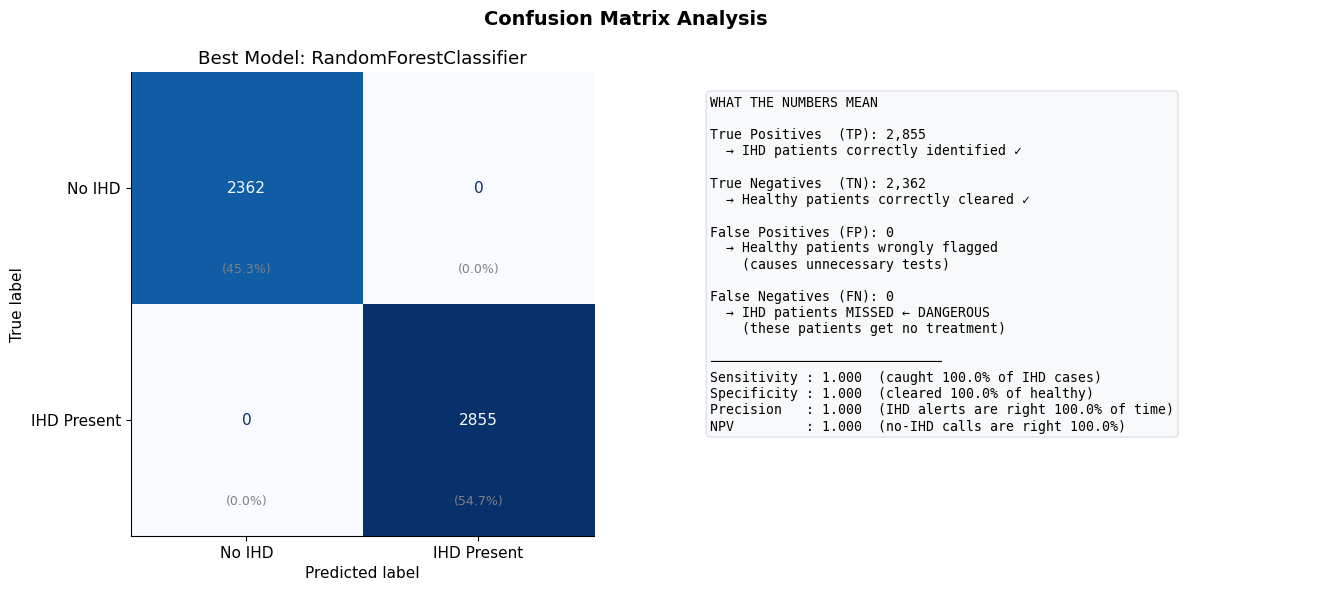

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrix Analysis", fontsize=14, fontweight="bold")

# ── LEFT: The confusion matrix chart ───────────────────────

cm = confusion_matrix(y_test_ev, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["No IHD", "IHD Present"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Best Model: {model_name}")

# Add the percentage below each count
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        axes[0].text(j, i + 0.35,
                    f"({pct:.1f}%)",
                    ha="center", va="center", fontsize=9, color="gray")

# ── RIGHT: Plain English explanation of each cell ──────────

tn, fp, fn, tp = cm.ravel()   # unpack the 4 cells in order
sensitivity = tp / (tp + fn)   # what fraction of IHD patients did we catch?
specificity = tn / (tn + fp)   # what fraction of healthy patients did we correctly clear?
ppv = tp / (tp + fp)            # when we say IHD, how often are we right?
npv = tn / (tn + fn)            # when we say no IHD, how often are we right?

axes[1].axis("off")
explanation = (
    f"WHAT THE NUMBERS MEAN\n\n"
    f"True Positives  (TP): {tp:,}\n"
    f"  → IHD patients correctly identified ✓\n\n"
    f"True Negatives  (TN): {tn:,}\n"
    f"  → Healthy patients correctly cleared ✓\n\n"
    f"False Positives (FP): {fp:,}\n"
    f"  → Healthy patients wrongly flagged\n"
    f"    (causes unnecessary tests)\n\n"
    f"False Negatives (FN): {fn:,}\n"
    f"  → IHD patients MISSED ← DANGEROUS\n"
    f"    (these patients get no treatment)\n\n"
    f"─────────────────────────────\n"
    f"Sensitivity : {sensitivity:.3f}  (caught {sensitivity*100:.1f}% of IHD cases)\n"
    f"Specificity : {specificity:.3f}  (cleared {specificity*100:.1f}% of healthy)\n"
    f"Precision   : {ppv:.3f}  (IHD alerts are right {ppv*100:.1f}% of time)\n"
    f"NPV         : {npv:.3f}  (no-IHD calls are right {npv*100:.1f}%)"
)

axes[1].text(0.05, 0.95, explanation,
             transform=axes[1].transAxes,
             va="top", fontsize=9.5, fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#f8f9fa", edgecolor="#dee2e6"))

plt.tight_layout()
plt.show()

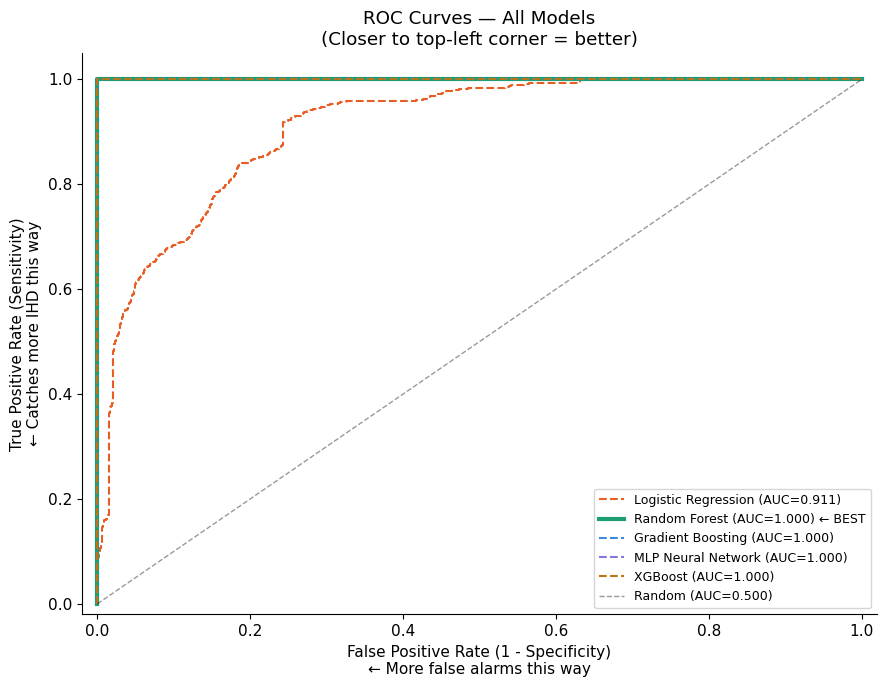

In [52]:
fig, ax = plt.subplots(figsize=(9, 7))

model_colors = {
    "Logistic Regression" : "#E85D24",
    "Random Forest"       : "#1D9E75",
    "Gradient Boosting"   : "#378ADD",
    "MLP Neural Network"  : "#7F77DD",
    "XGBoost"             : "#BA7517",
}

X_train_eval_sc = pd.DataFrame(scaler_loaded.transform(X_train_ev), columns=X_eval.columns)

all_model_names = list(models.keys())

for name in all_model_names:
    model_path = f"outputs/models/{name.lower().replace(' ', '_')}.pkl"
    if not os.path.exists(model_path):
        continue

    with open(model_path, "rb") as f:
        m = pickle.load(f)

    probs = m.predict_proba(X_test_ev_scaled)[:, 1]

    # roc_curve returns false positive rate, true positive rate, and threshold values
    fpr, tpr, thresholds = roc_curve(y_test_ev, probs)
    auroc = auc(fpr, tpr)

    is_best = (name == best_model_name)
    ax.plot(
        fpr, tpr,
        color=model_colors.get(name, "gray"),
        lw=3 if is_best else 1.5,
        linestyle="-" if is_best else "--",
        label=f"{name} (AUC={auroc:.3f})" + (" ← BEST" if is_best else "")
    )

# The diagonal line = random guessing (AUC = 0.5)
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random (AUC=0.500)")

ax.set_xlabel("False Positive Rate (1 - Specificity)\n← More false alarms this way")
ax.set_ylabel("True Positive Rate (Sensitivity)\n← Catches more IHD this way")
ax.set_title("ROC Curves — All Models\n(Closer to top-left corner = better)")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])

plt.tight_layout()
plt.show()

Computing SHAP values (this may take 1-2 minutes)...
✓ SHAP values computed for 500 patients
  Shape: (500, 27, 2) (patients × features)

Generating SHAP beeswarm plot...


<Figure size 1000x800 with 0 Axes>

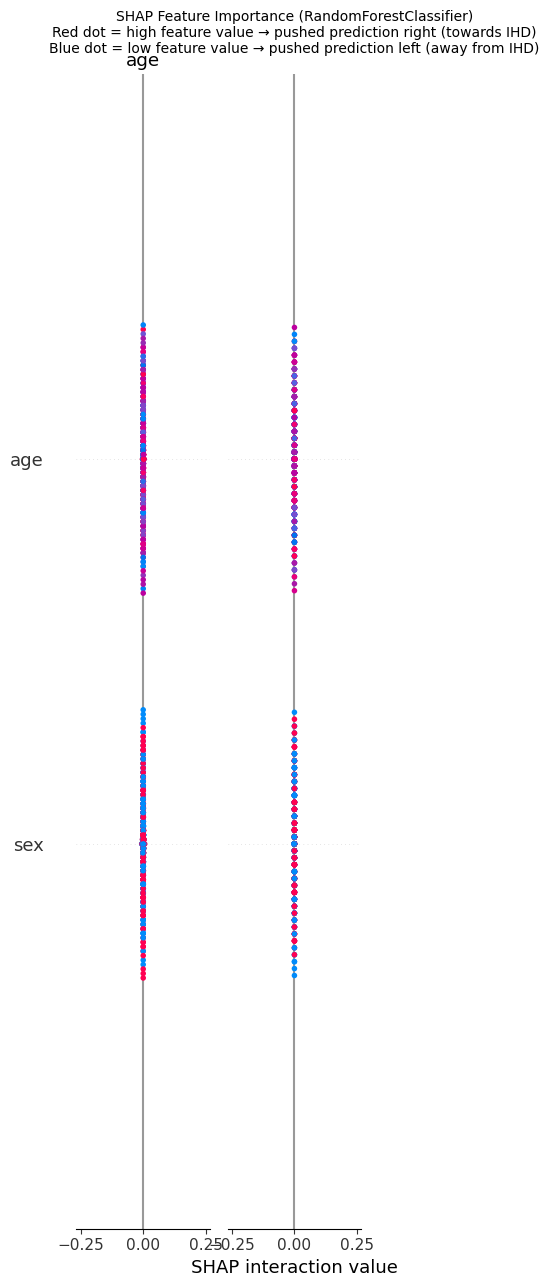

Generating SHAP bar plot...


<Figure size 1000x700 with 0 Axes>

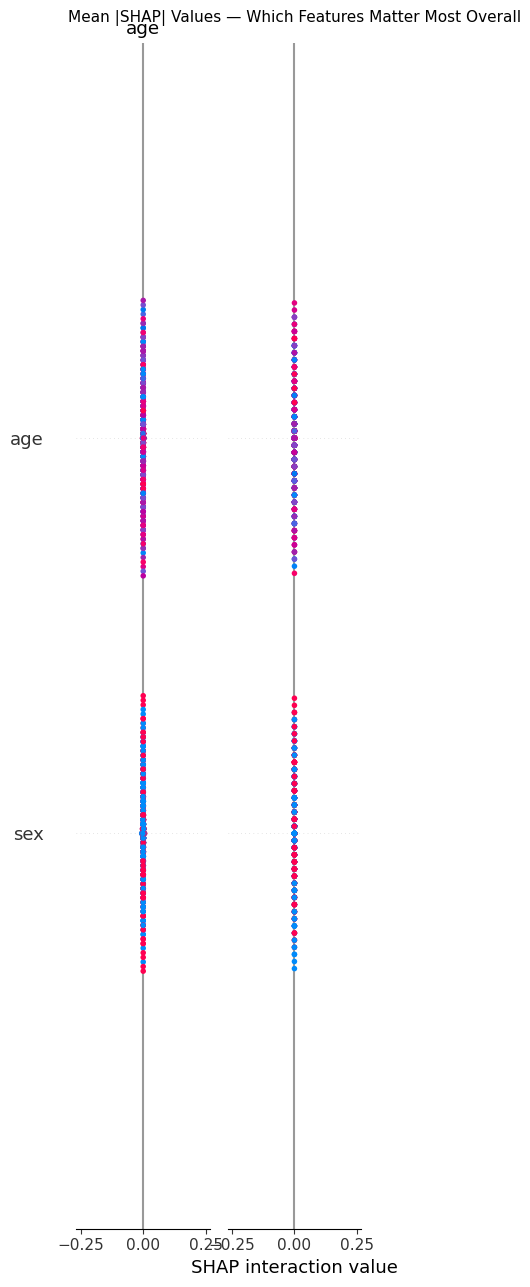

In [55]:
try:
    import shap

    print("Computing SHAP values (this may take 1-2 minutes)...")

    # TreeExplainer works with tree-based models (Random Forest, XGBoost, Gradient Boosting)
    # It's much faster than KernelExplainer
    model_class = type(best_model).__name__

    if model_class in ["RandomForestClassifier", "GradientBoostingClassifier", "XGBClassifier"]:
        explainer = shap.TreeExplainer(best_model)
    else:
        # KernelExplainer works with any model but is slower
        # We use a small background sample to speed it up
        background = shap.sample(X_train_eval_sc, 100, random_state=42)
        explainer  = shap.KernelExplainer(best_model.predict_proba, background)

    # Use a sample of test data for speed (500 patients is enough for a clear plot)
    sample_size = min(500, len(X_test_ev_scaled))
    X_shap = X_test_ev_scaled.iloc[:sample_size]

    # shap_values returns an array of shape [n_patients, n_features]
    # Each value tells you: "how much did this feature move the prediction for this patient?"
    shap_values = explainer.shap_values(X_shap)

    # For binary classification, shap_values is a list [class_0_values, class_1_values]
    # We want class 1 (IHD positive)
    if isinstance(shap_values, list):
        shap_vals_positive = shap_values[1]
    else:
        shap_vals_positive = shap_values

    print(f"✓ SHAP values computed for {sample_size} patients")
    print(f"  Shape: {shap_vals_positive.shape} (patients × features)")

    # ── SHAP Beeswarm Plot ────────────────────────────────────
    # Each row = one feature
    # Each dot = one patient
    # Dot colour = the feature's value for that patient (red=high, blue=low)
    # Dot position = how much that feature pushed the prediction

    print("\nGenerating SHAP beeswarm plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_vals_positive,
        X_shap,
        plot_type="dot",
        max_display=15,   # show top 15 most important features
        show=False
    )
    plt.title(f"SHAP Feature Importance ({model_class})\n"
              f"Red dot = high feature value → pushed prediction right (towards IHD)\n"
              f"Blue dot = low feature value → pushed prediction left (away from IHD)",
              fontsize=10, pad=15)
    plt.tight_layout()
    plt.show()

    # ── SHAP Bar Plot ─────────────────────────────────────────
    # Simpler view: just the average impact of each feature
    # Bar length = average |SHAP value| across all patients
    print("Generating SHAP bar plot...")
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_vals_positive,
        X_shap,
        plot_type="bar",
        max_display=15,
        show=False
    )
    plt.title("Mean |SHAP| Values — Which Features Matter Most Overall",
              fontsize=11, pad=15)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("SHAP not installed. Run: pip install shap")

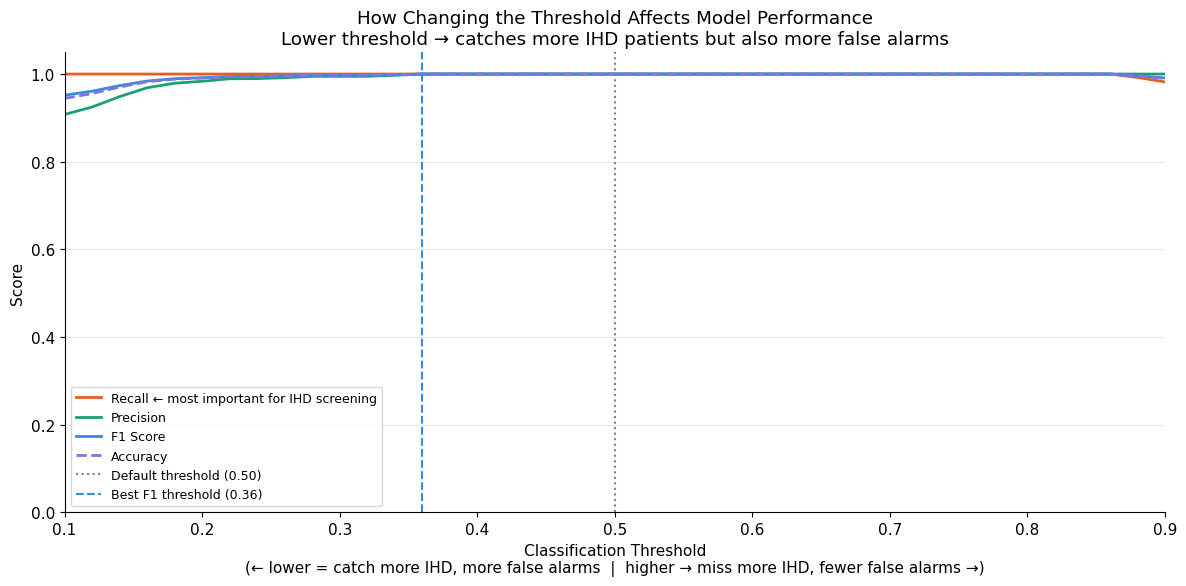


At default threshold (0.50):
  Recall    : 1.000
  Precision : 1.000

At best F1 threshold (0.36):
  Recall    : 1.000
  Precision : 1.000


In [56]:
# We test every threshold from 10% to 90% in steps of 2%
thresholds = np.arange(0.1, 0.91, 0.02)

precisions, recalls, f1s, accuracies = [], [], [], []

for threshold in thresholds:
    # Convert probabilities to 0/1 predictions using this threshold
    # If probability >= threshold, predict IHD (1), otherwise predict no IHD (0)
    preds = (y_pred_prob >= threshold).astype(int)

    precisions.append(precision_score(y_test_ev, preds, zero_division=0))
    recalls.append(recall_score(y_test_ev, preds, zero_division=0))
    f1s.append(f1_score(y_test_ev, preds, zero_division=0))
    accuracies.append(accuracy_score(y_test_ev, preds))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thresholds, recalls,    color="#E85D24", lw=2, label="Recall ← most important for IHD screening")
ax.plot(thresholds, precisions, color="#1D9E75", lw=2, label="Precision")
ax.plot(thresholds, f1s,        color="#378ADD", lw=2, label="F1 Score")
ax.plot(thresholds, accuracies, color="#7F77DD", lw=2, label="Accuracy", linestyle="--")

# Show default threshold
ax.axvline(0.5, color="gray", linestyle=":", lw=1.5, label="Default threshold (0.50)")

# Show optimal F1 threshold
best_f1_idx = np.argmax(f1s)
best_f1_thresh = thresholds[best_f1_idx]
ax.axvline(best_f1_thresh, color="#378ADD", linestyle="--", lw=1.5,
           label=f"Best F1 threshold ({best_f1_thresh:.2f})")

ax.set_xlabel("Classification Threshold\n(← lower = catch more IHD, more false alarms  |  higher → miss more IHD, fewer false alarms →)")
ax.set_ylabel("Score")
ax.set_title("How Changing the Threshold Affects Model Performance\n"
             "Lower threshold → catches more IHD patients but also more false alarms")
ax.legend(fontsize=9)
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0, 1.05])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAt default threshold (0.50):")
preds_50 = (y_pred_prob >= 0.50).astype(int)
print(f"  Recall    : {recall_score(y_test_ev, preds_50):.3f}")
print(f"  Precision : {precision_score(y_test_ev, preds_50):.3f}")

print(f"\nAt best F1 threshold ({best_f1_thresh:.2f}):")
preds_best = (y_pred_prob >= best_f1_thresh).astype(int)
print(f"  Recall    : {recall_score(y_test_ev, preds_best):.3f}")
print(f"  Precision : {precision_score(y_test_ev, preds_best):.3f}")

In [57]:
print("=" * 60)
print("FULL CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test_ev, y_pred, target_names=["No IHD", "IHD Present"]))

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Model        : {model_name}")
print(f"Test samples : {len(y_test_ev):,}")
print(f"Accuracy     : {accuracy_score(y_test_ev, y_pred):.4f}")
print(f"Precision    : {precision_score(y_test_ev, y_pred):.4f}")
print(f"Recall       : {recall_score(y_test_ev, y_pred):.4f}")
print(f"F1 Score     : {f1_score(y_test_ev, y_pred):.4f}")
print(f"AUROC        : {roc_auc_score(y_test_ev, y_pred_prob):.4f}")
print("\nNote: Recall is the most critical metric for medical screening.")
print("A missed IHD case (false negative) is more dangerous than a false alarm.")

FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      No IHD       1.00      1.00      1.00      2362
 IHD Present       1.00      1.00      1.00      2855

    accuracy                           1.00      5217
   macro avg       1.00      1.00      1.00      5217
weighted avg       1.00      1.00      1.00      5217


FINAL SUMMARY
Model        : RandomForestClassifier
Test samples : 5,217
Accuracy     : 1.0000
Precision    : 1.0000
Recall       : 1.0000
F1 Score     : 1.0000
AUROC        : 1.0000

Note: Recall is the most critical metric for medical screening.
A missed IHD case (false negative) is more dangerous than a false alarm.
